# Exploratory Data Analysis — Healthcare Dataset

## Přehled datasetu

Tento notebook obsahuje explorační analýzu zdravotnického datasetu.  
Dataset obsahuje záznamy o pacientech, například demografické údaje, diagnózu, informace o přijetí, pojišťovnu, výši účtu, délku hospitalizace a výsledky testů.

Cílem analýzy je porozumět struktuře datasetu, najít základní vzorce v datech a odpovědět na vybrané analytické otázky týkající se demografie pacientů, diagnóz, délky hospitalizace, výše účtů a výsledků testů.


## Sloupce v datasetu

| Column | Popis |
|---|---|
| Name | Jméno pacienta |
| Age | Věk pacienta v době přijetí |
| Gender | Pohlaví pacienta |
| Blood Type | Krevní skupina pacienta |
| Medical Condition | Primární diagnóza nebo zdravotní stav pacienta |
| Date of Admission | Datum přijetí pacienta do zdravotnického zařízení |
| Doctor | Lékař odpovědný za péči o pacienta |
| Hospital | Zdravotnické zařízení, do kterého byl pacient přijat |
| Insurance Provider | Pojišťovna pacienta |
| Billing Amount | Částka účtovaná za zdravotnické služby |
| Room Number | Číslo pokoje, kde byl pacient ubytován |
| Admission Type | Typ přijetí pacienta: Emergency, Elective nebo Urgent |
| Discharge Date | Datum propuštění pacienta ze zdravotnického zařízení |
| Medication | Předepsaný nebo podaný lék |
| Test Results | Výsledek testu: Normal, Abnormal nebo Inconclusive |

## Analytické otázky

Analýza se zaměřuje na následující otázky:

1. Jaké je rozložení pacientů podle věku a pohlaví? Která věková skupina je nejčastěji hospitalizována?
2. Které diagnózy jsou v datasetu nejčastější? Liší se diagnózy podle pohlaví nebo věkové skupiny?
3. Jaká je průměrná výše účtu podle diagnózy, pojišťovny a typu přijetí?
4. Jaká je průměrná délka hospitalizace? Liší se podle diagnózy nebo typu přijetí?
5. Jak se liší výsledky testů podle diagnózy nebo věkové skupiny?

In [ ]:
# Import knihoven
import pandas as pd
import seaborn as sns
import importlib
import matplotlib.pyplot as plt


In [65]:
# Načtení datasetu
df = pd.read_csv("../data/healthcare_dataset_cleaned.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 1.  Demografické: Jaké je rozložení pacientů podle věku a pohlaví? Která věková skupina je nejčastěji hospitalizována?

In [5]:
#1.1 Rozdělení pacientů podle věku
df["Age"].describe()

count    54966.000000
mean        51.535185
std         19.605661
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                54966 non-null  object 
 1   Age                 54966 non-null  int64  
 2   Gender              54966 non-null  object 
 3   Blood Type          54966 non-null  object 
 4   Medical Condition   54966 non-null  object 
 5   Date of Admission   54966 non-null  object 
 6   Doctor              54966 non-null  object 
 7   Hospital            54966 non-null  object 
 8   Insurance Provider  54966 non-null  object 
 9   Billing Amount      54966 non-null  float64
 10  Room Number         54966 non-null  int64  
 11  Admission Type      54966 non-null  object 
 12  Discharge Date      54966 non-null  object 
 13  Medication          54966 non-null  object 
 14  Test Results        54966 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.3

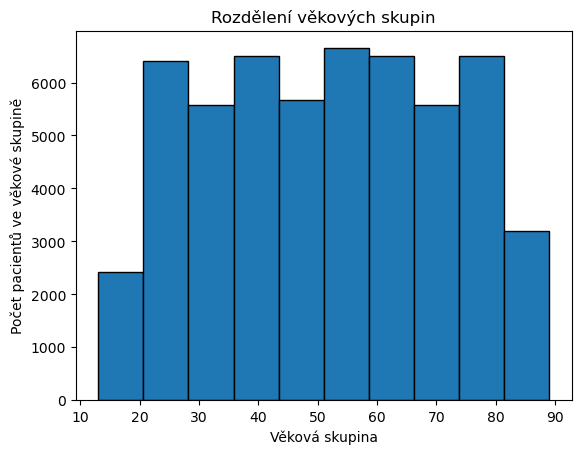

In [ ]:
# Histogram rozdělení vekových skupin
plt.hist(df["Age"], bins=10, edgecolor="black")
plt.title("Rozdělení věkových skupin")
plt.xlabel("Věková skupina")
plt.ylabel("Počet pacientů ve věkové skupině")
plt.show()

In [43]:
#1.2 Zastoupení pohlaví
df['Gender'].value_counts()

Gender
Male      27496
Female    27470
Name: count, dtype: int64

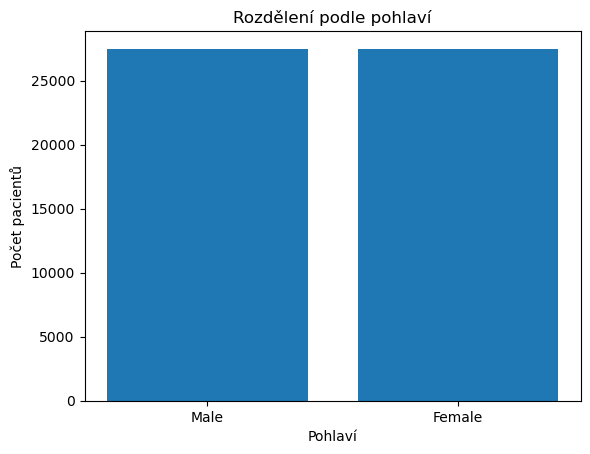

In [ ]:
#Rozdělení podle pohlaví graf
plt.bar(df['Gender'].value_counts().index, df['Gender'].value_counts())
plt.title("Rozdělení podle pohlaví")
plt.xlabel("Pohlaví")
plt.ylabel("Počet pacientů")
plt.show()


In [46]:
#1.3 Rozdělení podle pohlaví a věku
df.groupby("Gender")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,27470.0,51.584419,19.67254,13.0,35.0,52.0,69.0,89.0
Male,27496.0,51.485998,19.53885,13.0,35.0,52.0,68.0,89.0


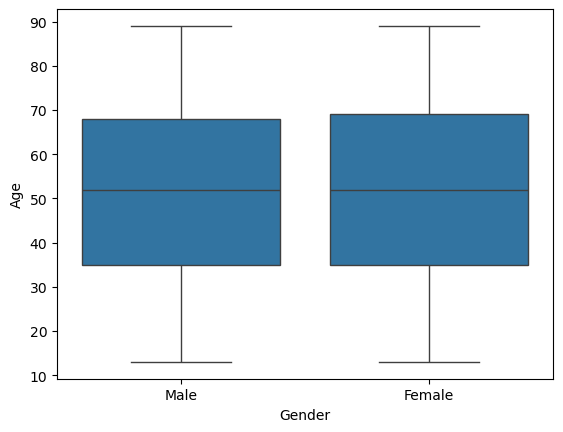

In [47]:
# Rozdělení podle pohlaví a věku graf
sns.boxplot(data=df, x= df['Gender'], y=df["Age"])
plt.show()

## Závěr k otázce č. 1 ##

Věk pacientů se pohybuje od 13 do 89 let. Průměrný věk je přibližně 51,5 roku a medián 52 let, což ukazuje na poměrně symetrické rozložení. Histogram neukazuje výrazně dominantní věkovou skupinu. Rozložení působí poměrně rovnoměrně, což může naznačovat, že dataset je syntetický nebo uměle vyvážený.

Zastoupení mužů a žen je téměř totožné. V datasetu je 27 496 mužů a 27 470 žen, rozdíl je tedy velmi malý. Na základě těchto počtů nelze pozorovat výraznou nerovnováhu mezi pohlavími.

Rozložení věku podle pohlaví je velmi podobné. Muži i ženy mají stejný medián věku 52 let a podobný rozsah hodnot od 13 do 89 let. Ani boxplot neukazuje výrazný rozdíl mezi pohlavími.

## 2. Diagnózy: Která onemocnění jsou nejčastější? Liší se diagnózy podle pohlaví nebo věkové skupiny?

In [48]:
#2.1 Zastoupení jednotlivých onemocnění v datasetu
df["Medical Condition"].value_counts() 

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

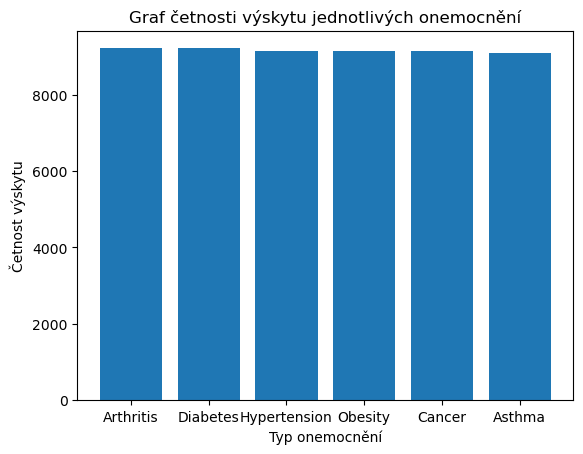

In [12]:
#Grafické zobrazení výskytu onemocnění
plt.bar(df["Medical Condition"].value_counts().index, df["Medical Condition"].value_counts())
plt.title("Graf četnosti výskytu jednotlivých onemocnění")
plt.xlabel("Typ onemocnění")
plt.ylabel("Četnost výskytu")
plt.show()

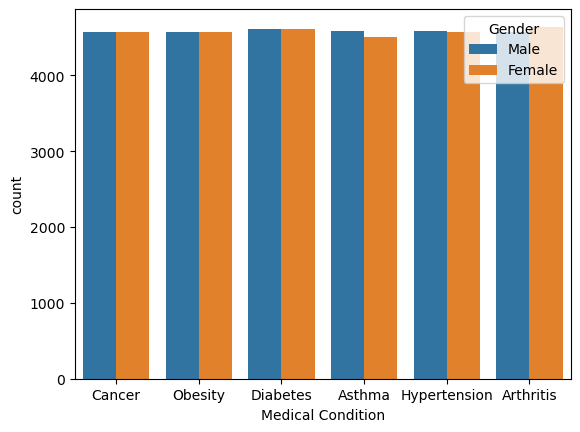

In [49]:
#2.2 Diagnózy podle pohlaví
sns.countplot(x="Medical Condition", hue="Gender", data=df)
plt.show()

In [93]:
#2.3. Diagnózy podle věku
bins = [10, 20, 30, 40, 50, 60, 70, 80, 90]
labels = ["11–20", "21–30", "31–40", "41–50", "51–60", "61–70", "71–80", "81–90"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)


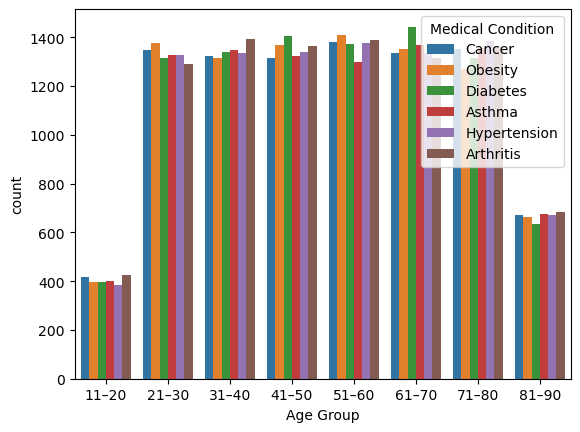

In [94]:
# Grafické znázornění diagnóz podle věku
sns.countplot(x="Age Group", hue="Medical Condition", data=df)
plt.show()

## Závěr k otázce číslo 2 ##

Nejčastější diagnózou je Arthritis, ale rozdíl oproti ostatním diagnózám je velmi malý. Všechny diagnózy se v datasetu vyskytují s podobnou četností, což opět působí jako uměle vyvážené rozložení.

Rozložení diagnóz mezi muži a ženami je velmi podobné. U žádné diagnózy není vidět výrazná převaha jednoho pohlaví. Dataset tedy neukazuje zjevnou souvislost mezi pohlavím a typem diagnózy.

Diagnózy jsou napříč věkovými skupinami rozloženy poměrně rovnoměrně. Ve většině věkových kategorií se počty jednotlivých diagnóz výrazně neliší. Výjimkou jsou skupiny 11–20 a 81–90 let, kde je celkový počet pacientů nižší. U skupiny 11–20 let to může být způsobeno tím, že data začínají až od 13 let. Graf tedy neukazuje výraznou závislost mezi věkem pacienta a typem diagnózy. Vyrovnanost hodnot může naznačovat syntetický nebo uměle vyvážený charakter datasetu.

## 3.Finance: Jaká je průměrná výše účtu podle diagnózy / pojišťovny / typu přijetí? Která pojišťovna "platí nejvíce"?

In [95]:
##3.1 Průměrná výše účtu podle diagnózy

billing_by_conditions = df.groupby("Medical Condition")["Billing Amount"].mean()
billing_by_conditions.sort_values(ascending=False)

Medical Condition
Obesity         25804.361902
Diabetes        25660.478635
Asthma          25633.461696
Arthritis       25511.783246
Hypertension    25503.058720
Cancer          25152.322947
Name: Billing Amount, dtype: float64

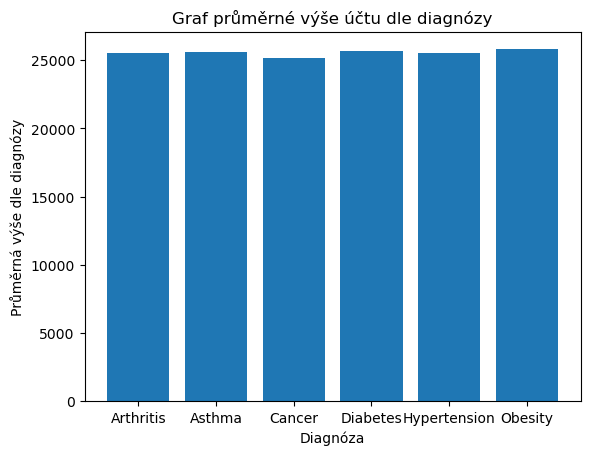

In [96]:
## Grafické znázornění průměrná výše účtu podle diagnózy
plt.bar (billing_by_conditions.index, billing_by_conditions.values)
plt.title("Graf průměrné výše účtu dle diagnózy")
plt.ylabel("Průměrná výše dle diagnózy")
plt.xlabel("Diagnóza")
plt.show()

In [97]:
##3.2 Průměrná výše účtu podle pojišťovny

billing_by_insurance = df.groupby("Insurance Provider")["Billing Amount"].mean()
billing_by_insurance.sort_values(ascending=False)

Insurance Provider
Medicare            25628.320208
Blue Cross          25603.460603
Aetna               25549.689648
Cigna               25525.998670
UnitedHealthcare    25414.506208
Name: Billing Amount, dtype: float64

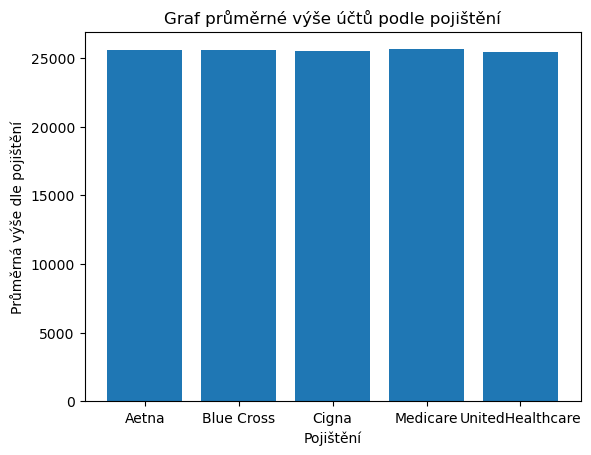

In [98]:
## Grafické znázornění průměrná výše účtu podle pojišťovny
plt.bar (billing_by_insurance.index, billing_by_insurance.values)
plt.title("Graf průměrné výše účtů podle pojištění")
plt.ylabel("Průměrná výše dle pojištění")
plt.xlabel("Pojištění")
plt.show()

In [99]:
##3.3 Průměrná výše účtu podle typu přijetí pacientů

billing_by_admission_type = df.groupby("Admission Type")["Billing Amount"].mean()
billing_by_admission_type.sort_values(ascending=False)

Admission Type
Elective     25612.139673
Urgent       25514.532045
Emergency    25505.332240
Name: Billing Amount, dtype: float64

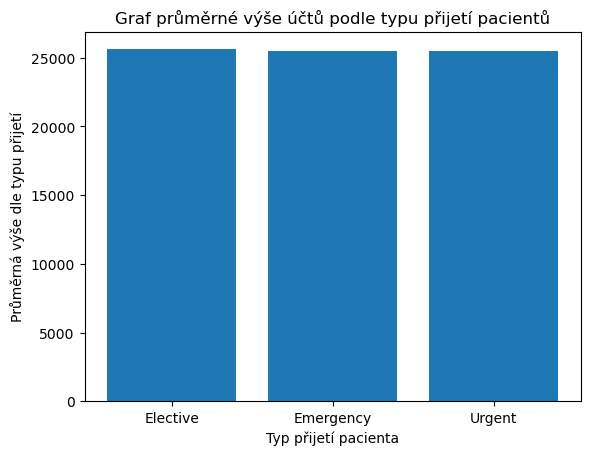

In [100]:
## Grafické znázornění průměrná výše účtu podle typu přijetí pacientů
plt.bar (billing_by_admission_type.index, billing_by_admission_type.values)
plt.title("Graf průměrné výše účtů podle typu přijetí pacientů")
plt.ylabel("Průměrná výše dle typu přijetí")
plt.xlabel("Typ přijetí pacienta")
plt.show()

## Závěr pro otázku 3 ##

Průměrná výše účtu se mezi jednotlivými diagnózami, pojišťovnami i typy přijetí výrazně neliší. Nejvyšší průměrný účet mají pacienti s diagnózou Obesity, přibližně 25 804. Z pojišťoven má nejvyšší průměrnou hodnotu Medicare, přibližně 25 612. Podle typu přijetí je nejvyšší průměrná hodnota u Elective, přibližně 25 612. Rozdíly mezi kategoriemi jsou však velmi malé, proto nelze říci, že by některá skupina výrazně dominovala. Výsledky opět naznačují poměrně vyvážený charakter datasetu.

## 4. Provoz nemocnice: Jak dlouho pacienti průměrně leží v nemocnici (délka hospitalizace)? Liší se to podle diagnózy nebo typu přijetí?

In [101]:
#Předevední textu na datum
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Name                       54966 non-null  object        
 1   Age                        54966 non-null  int64         
 2   Gender                     54966 non-null  object        
 3   Blood Type                 54966 non-null  object        
 4   Medical Condition          54966 non-null  object        
 5   Date of Admission          54966 non-null  datetime64[ns]
 6   Doctor                     54966 non-null  object        
 7   Hospital                   54966 non-null  object        
 8   Insurance Provider         54966 non-null  object        
 9   Billing Amount             54966 non-null  float64       
 10  Room Number                54966 non-null  int64         
 11  Admission Type             54966 non-null  object        
 12  Disc

In [102]:
# Vytvoření nového sloupce Length of Hospitalization
df["Length of Hospitalization"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days


In [ ]:
# Kontrola vytvořeného sloupce
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Hospitalization
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [104]:
#4.1 Průměrná délka hospitalizace
df["Length of Hospitalization"].mean()

np.float64(15.499290470472657)

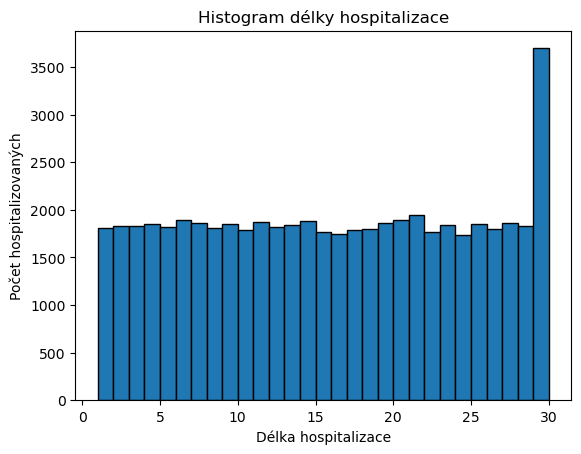

In [105]:
#Grafické znázornění délky hospitalizace

plt.hist(df["Length of Hospitalization"], bins="auto", edgecolor="black")
plt.title("Histogram délky hospitalizace")
plt.xlabel("Délka hospitalizace")
plt.ylabel("Počet hospitalizovaných")
plt.show()

### Kontrola hodnoty 30 dní hospitalizace

V histogramu je vidět výrazně vyšší počet pacientů s délkou hospitalizace přesně 30 dní.  
Proto byla tato hodnota ověřena samostatně pomocí filtrace dat.

Výsledkem je, že přesně 30 dní hospitalizace má 1 854 pacientů. Zároveň je 30 dní maximální hodnota délky hospitalizace v datasetu.

To může naznačovat, že hodnota 30 dní představuje horní hranici nebo limit použitý při tvorbě datasetu.

In [106]:
#Kolik pacientů má přesně 30 dní hospitalizace
df[df["Length of Hospitalization"] == 30].shape

(1854, 17)

In [107]:
#Maximální doba hospitalizace
df["Length of Hospitalization"].max()

30

In [108]:
#4.2. Délka hospitalizace podle diagnózy?
df.groupby("Medical Condition")["Length of Hospitalization"].mean()

Medical Condition
Arthritis       15.504231
Asthma          15.677295
Cancer          15.501204
Diabetes        15.430664
Hypertension    15.436236
Obesity         15.447627
Name: Length of Hospitalization, dtype: float64

In [109]:
# 4.3. 4.2. Délka hospitalizace podle typu přijetí?
df.groupby("Admission Type")["Length of Hospitalization"].mean()

Admission Type
Elective     15.511178
Emergency    15.584134
Urgent       15.403839
Name: Length of Hospitalization, dtype: float64

## Závěr k otázce č. 4
Průměrná délka hospitalizace je přibližně 15,5 dne. Délka hospitalizace se pohybuje maximálně do 30 dní. V datech je patrné zvýšené množství pacientů s hospitalizací přesně 30 dní, což může souviset s tím, že 30 dní je horní limit v datasetu. Průměrná délka hospitalizace se podle diagnózy ani typu přijetí výrazně neliší.

 ## 5.  Výsledky testů: Jak se liší výsledky testů podle diagnózy nebo věku?

In [110]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Hospitalization,Age Group
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,21–30
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,61–70
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,71–80
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,21–30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,41–50


In [111]:
df["Test Results"].unique()

array(['Normal', 'Inconclusive', 'Abnormal'], dtype=object)

In [112]:
#5.1. Výsledky testů posle diagnozy
df.groupby("Medical Condition")["Test Results"].value_counts()

Medical Condition  Test Results
Arthritis          Abnormal        3156
                   Inconclusive    3062
                   Normal          3000
Asthma             Normal          3116
                   Inconclusive    2999
                   Abnormal        2980
Cancer             Abnormal        3089
                   Inconclusive    3033
                   Normal          3018
Diabetes           Abnormal        3131
                   Normal          3061
                   Inconclusive    3024
Hypertension       Normal          3106
                   Inconclusive    3068
                   Abnormal        2977
Obesity            Abnormal        3104
                   Normal          3030
                   Inconclusive    3012
Name: count, dtype: int64

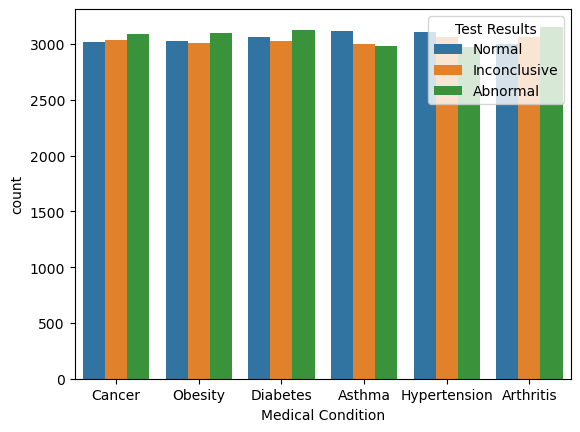

In [113]:
#5.2. výsledky testů podle diagnózy
sns.countplot(x="Medical Condition", hue="Test Results", data=df)
plt.show()

In [ ]:
#5.3. Výsledky testů posle věku
df.groupby("Age Group")["Test Results"].value_counts().sort_values(ascending=False)

C:\Users\danie\AppData\Local\Temp\ipykernel_21600\666770182.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age Group")["Test Results"].value_counts().sort_values(ascending=False)


Age Group  Test Results
51–60      Abnormal        2808
21–30      Normal          2755
61–70      Inconclusive    2745
51–60      Inconclusive    2734
61–70      Abnormal        2734
71–80      Abnormal        2721
41–50      Inconclusive    2715
31–40      Normal          2710
41–50      Abnormal        2705
71–80      Normal          2700
41–50      Normal          2696
31–40      Abnormal        2692
51–60      Normal          2680
61–70      Normal          2666
31–40      Inconclusive    2649
21–30      Abnormal        2627
71–80      Inconclusive    2611
21–30      Inconclusive    2602
81–90      Inconclusive    1355
           Abnormal        1335
           Normal          1305
11–20      Normal           819
           Abnormal         815
           Inconclusive     787
Name: count, dtype: int64

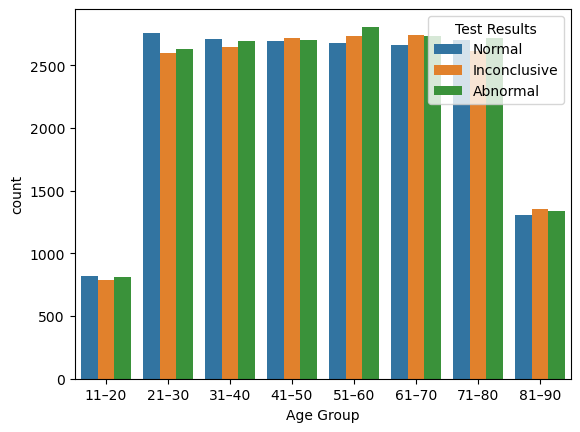

In [120]:
#5.4. výsledky testů podle věku
sns.countplot(x="Age Group", hue="Test Results", data=df)
plt.show()

In [121]:
df.groupby("Age Group").size().sort_values(ascending=False)

C:\Users\danie\AppData\Local\Temp\ipykernel_21600\620113243.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age Group").size().sort_values(ascending=False)


Age Group
51–60    8222
61–70    8145
41–50    8116
31–40    8051
71–80    8032
21–30    7984
81–90    3995
11–20    2421
dtype: int64

## Závěr k otázce č. 5

Výsledky testů (Normal, Abnormal, Inconclusive) se výrazně neliší ani podle diagnózy, ani podle věkové skupiny. Hodnoty jsou napříč všemi kategoriemi velmi vyrovnané. 
Nižší počty u věkových skupin 11–20 a 81–90 jsou způsobeny celkově menším počtem pacientů v těchto skupinách, nikoliv odlišným vzorcem výsledků. 
Celková vyváženost výsledků testů může opět naznačovat syntetický nebo uměle vyvážený charakter datasetu.

## Hlavní závěry

- Věk pacientů je rozložen poměrně rovnoměrně, nejčastější věková skupina je 61–70 let.
- Pohlaví pacientů je téměř vyrovnané.
- Diagnózy jsou v datasetu rozloženy velmi rovnoměrně.
- Není patrný výrazný rozdíl v diagnózách podle pohlaví ani věkové skupiny.
- Průměrná výše účtu se mezi diagnózami, pojišťovnami a typy přijetí výrazně neliší.
- Průměrná délka hospitalizace je přibližně 15,5 dne.
- Délka hospitalizace se výrazně neliší podle diagnózy ani typu přijetí.
- Hodnota 30 dní hospitalizace se objevuje častěji a zároveň je maximální hodnotou, což může naznačovat horní limit datasetu.
- Výsledky testů jsou napříč diagnózami i věkovými skupinami poměrně vyrovnané.
- Celková vyváženost dat může naznačovat syntetický nebo uměle vytvořený dataset.

In [123]:
df.to_csv("../data/healthcare_dataset_cleaned_added_columns.csv", index=False)